# Redes Neuronales: Perceptrón Multicapa (MLP)

## Introducción

En este notebook vamos a trabajar con una **red neuronal artificial de tipo Perceptrón Multicapa (MLP)** utilizando la librería `scikit-learn`.

El objetivo principal es comprender cómo funciona una red neuronal en un problema real de **clasificación o regresión**, centrándonos en tres aspectos clave:

- Cómo preparar los datos para que puedan ser utilizados por un modelo de Machine Learning.
- Cómo entrenar una red neuronal.
- Cómo evaluar su rendimiento y analizar los resultados.

---

## ¿Qué es un Perceptrón Multicapa?

Un perceptrón multicapa es una extensión del perceptrón simple que:
- Permite trabajar con problemas más complejos.
- Introduce **capas ocultas** entre la entrada y la salida.
- Utiliza funciones de activación no lineales.

Esto permite modelar relaciones **no lineales**, algo que el perceptrón monocapa no puede hacer.

---

## Flujo de trabajo que vamos a seguir

A lo largo de este notebook seguiremos el pipeline típico de Machine Learning:

1. **Carga y preprocesado de datos**
2. **Transformación de variables categóricas**
3. **División en conjunto de entrenamiento y test**
4. **Entrenamiento del modelo (MLP)**
5. **Evaluación de resultados**
6. **Optimización de hiperparámetros (GridSearch)**

---

## Objetivo didáctico

No se trata solo de ejecutar código, sino de:

- Entender qué hace cada bloque.
- Interpretar los resultados del modelo.
- Comprender las decisiones de diseño (preprocesado, parámetros, etc.).
- Relacionar la teoría de redes neuronales con su implementación práctica.

---

## Importante

Las redes neuronales trabajan exclusivamente con datos numéricos, por lo que el preprocesado de los datos será una parte fundamental del proceso.

Además, aunque utilizamos `scikit-learn` para simplificar la implementación, es importante entender qué ocurre internamente en el modelo.

---

## Resultado esperado

Al finalizar este notebook, deberías ser capaz de:

- Entrenar un perceptrón multicapa desde cero con `scikit-learn`
- Interpretar su comportamiento
- Detectar posibles problemas en los datos o en el modelo
- Entender cuándo este tipo de modelo es adecuado y cuándo no

---

# Inicialización

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV
from numpy import log
import warnings
warnings.filterwarnings('ignore')

## Función de preprocesado de datos

En este bloque definimos una función que automatiza el preprocesado del dataset.

El objetivo es preparar los datos para que puedan ser utilizados por un modelo de Machine Learning, ya que:

- Las redes neuronales solo trabajan con datos numéricos
- Las variables categóricas deben transformarse
- Es necesario evitar inconsistencias en los tipos de datos

La función realiza:

- Detección de variables categóricas
- Codificación numérica (Label Encoding y One-Hot Encoding)
- Conversión de variables al formato adecuado

In [2]:
# FUNCIÓN DE PREPROCESADO
# --------------------------------------------------

def fit_dataset_to_tree(df):

    # Comprueba si una variable es categórica
    def isCategorical(serie):
        return serie.dtype.name == 'category'

    # Comprueba si una variable categórica tiene más de 2 valores distintos
    def hasManyLevels(serie):
        return len(serie.cat.categories) > 2

    # Selecciona columnas categóricas con más de 2 categorías
    dummyColumns = [column for column in df if isCategorical(df[column]) and hasManyLevels(df[column])]

    # Convierte esas variables en variables dummy (one-hot encoding)
    df = pd.get_dummies(df, columns=dummyColumns)

    # Para variables categóricas con pocos valores (binarias),
    # se convierten directamente en códigos numéricos
    for column in df:
        if isCategorical(df[column]):
            if not hasManyLevels(df[column]):
                df[column] = df[column].cat.codes

    return df

# Conjunto de datos

## Conjunto de datos `Telco-Customer-Churn`

Este dataset contiene información sobre clientes de telecomunicaciones.

El objetivo es predecir si un cliente va a abandonar el servicio (churn).

Incluye variables como:

- Datos demográficos
- Servicios contratados
- Facturación
- Tipo de contrato

Este es un problema de **clasificación binaria** (Sí / No).

El conjunto de datos constará de las siguientes variables de entrada:

* `customerID`: (variable cualitativa nominal) identificador del cliente.
* `gender`: (variable cualitativa nominal) sexo del cliente.
* `SeniorCitizen`: (variable cualitativa nominal) si el cliente está o no jubilado.
* `Partner`: (variable cualitativa nominal) si el cliente tiene o no pareja.
* `Dependents`: (variable cualitativa nominal) si el cliente tiene o no personas a su cargo.
* `tenure`: (variable cuantitativa discreta) número de meses de antigüedad del cliente en la compañía.
* `PhoneService`: (variable cualitativa nominal) si el cliente ha contratado o no el servicio de línea telefónica.
* `MultipleLines`: (variable cualitativa nominal) si el cliente ha contratado o no varias líneas.
* `InternetService` (variabla cualitativa nominal) tipo de servicio de internet contratado (DSL, Fiber optic, No).
* `OnlineSecurity`: (variable cualitativa nominal) si el cliente ha contratado el servicio de seguridad online por internet.
* `OnlineBackup`: (variable cualitativa nominal) si el cliente tiene contratado el servicio de copias de seguridad online.
* `DeviceProtection`: (variable cualitativa nominal) si el cliente ha contratado o no un seguro adicional de protección de dispositivos de conexión a internet.
* `TechSupport`: (variable cualitativa nominal) si el cliente ha contratado el servicio de soporte técnico ante averías de internet.
* `StreamingTV`: (variable cualitativa nominal) si el cliente ha contratado el servició de streaming de canales de televisión por internet.
* `StreamingMovies`: (variable cualitativa nominal) si el cliente ha contratado el servició de streaming de películas por internet.
* `Contract`: (variable cualitativa nominal) duración del contrato del cliente (mensual, anual, bianual).
* `PaperlessBilling`: (variable cualitativa nominal) si el cliente ha solicitado la factura electrónica en lugar de por papel.
* `PaymentMethod`: (variable cualitativa nominal) método de pago del cliente.
* `MonthlyCharges`: (variable cuantitativa continua) importe mensual cobrado al cliente.
* `TotalCharges`: (variable cuantitativa continua) importe total acumulado cobrado al cliente.

La variable de salida es `Churn` con dos únicos valores: `Yes` indica que el cliente ha abandonado la compañía y `No` que aún sigue en ella.

A continuación cargaremos el conjunto de datos, que se encuentra en formato `csv` haciendo uso de `pandas`:

In [3]:
telco_df = pd.read_csv("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv")

A continuación, analizaremos si el conjunto de datos ha inferido los tipos de las variables correctamente:

In [4]:
telco_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Podemos comprobar que la mayoría de variables **categóricas** han sido inferidas como tipo `object` por lo que tendremos que modificar su tipo. Además, la variable `TotalCharges` **cuantitativa continua** ha sido inferida también como `object`, cuando debería ser de tipo `float64`. A continuación solucionaremos estos problemas:

In [5]:
# Establecemos las siguientes variables como tipo categórico
categorical = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
               'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
               'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
for category in categorical:
  telco_df[category] = telco_df[category].astype("category")

Para transformar el importe total cobrado a tipo numérico haremos uso de la función de `pandas` `to_numeric`, la cual recibirá como parámetro la `Serie` a transformar en valor numérico y, además, qué hacer en caso de error durante la conversión. En nestro caso le hemos indicado el valor `coerce`, pidiéndole que establezca como valor ausente cada error:

In [6]:
telco_df['TotalCharges'] = pd.to_numeric(telco_df['TotalCharges'], errors='coerce')

Además, asignaremos el identificador de cliente como índice de nuestro `DataFrame`:

In [7]:
if 'customerID' in telco_df.columns:
  telco_df = telco_df.set_index('customerID')

Podemos observar cómo ahora los tipos de nuestro conjunto de datos tienen ahora mucho más sentido:

In [8]:
telco_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   category
 1   SeniorCitizen     7043 non-null   category
 2   Partner           7043 non-null   category
 3   Dependents        7043 non-null   category
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   category
 6   MultipleLines     7043 non-null   category
 7   InternetService   7043 non-null   category
 8   OnlineSecurity    7043 non-null   category
 9   OnlineBackup      7043 non-null   category
 10  DeviceProtection  7043 non-null   category
 11  TechSupport       7043 non-null   category
 12  StreamingTV       7043 non-null   category
 13  StreamingMovies   7043 non-null   category
 14  Contract          7043 non-null   category
 15  PaperlessBilling  7043 non-null   category
 16  PaymentMethod 

Asumiendo que los datos están ya correctamente preprocesados (en su mayoría lo están), podemos proceder a mostrar la información estadística más relevante del conjunto de datos:

In [9]:
telco_df.describe(include='all')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043.0,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7032.000000,7043
unique,2,2.0,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,Male,0.0,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,3555,5901.0,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2283.300441,NaN
std,NaN,NaN,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.771362,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,401.450000,NaN
50%,NaN,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3794.737500,NaN


## Conjunto de datos `Forest Fires`

En este bloque trabajamos con un dataset sobre incendios forestales.

El objetivo es predecir la variable **area**, que representa la superficie quemada.

Se trata de un problema de **regresión**, ya que la variable objetivo es continua.

### Variables relevantes

- Variables espaciales (X, Y)
- Variables meteorológicas (temperatura, viento, humedad…)
- Índices del sistema FWI (FFMC, DMC, DC, ISI)
- Variable objetivo: área quemada

---

## Importante

A diferencia del dataset anterior (clasificación), aquí trabajamos con regresión, lo que implica:

- Métricas diferentes (error en lugar de accuracy)
- Mayor sensibilidad a outliers

El conjunto de datos constará de las siguientes variables de entrada (más información en el [artículo original](http://www3.dsi.uminho.pt/pcortez/fires.pdf)):

* `X`: (variable cuantitativa discreta) coordenada X del parque donde se originó el incendio.
* `Y`: (variable cuantitativa discreta) coordenada Y del parque donde se originó el incendio.
* `month`: (variable cualitativa **¿ordinal?**) mes en el que se produjo el incendio.
* `day`: (variable cualitativa **¿ordinal?**) día de la semana en que se produjo el incendio.
* `FFMC`: (variable cuantitativa continua) **F**ine **F**uel **M**oisture **C**ode, nivel de humedad en la basura superficial del parque.
* `DMC`: (variable cuantitativa continua) nivel de humedad de las capas orgánicas superficiales.
* `DC`: (variable cuantitativa continua) nivel de humedad de las capas orgánicas profundas.
* `ISI`: (variable cuantitativa continua) índice de velocidad de propagación del incendio.
* `temp` (variabla cuantitativa continua) temperatura en ºC.
* `RH`: (variable cuantitativa discreta) porcentaje de humedad relativa.
* `wind`: (variable cuantitativa continua) velocidad del viento en km/h.
* `rain`: (variable cuantitativa continua) cantidad de precipitaciones en $mm/m^2$.

La variable de salida es `area` con la **superficie en hectáreas** de bosque quemada.

A continuación cargaremos el conjunto de datos sobre el que trabajaremos:

In [10]:
#forest_df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/forest-fires/forestfires.csv")
forest_df = pd.read_csv("https://drive.google.com/uc?export=view&id=1cH5BPWPyZvnk0NO71C19VEDNALNkq-S3")
forest_df.head(3)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0


Es importante comprobar que los tipos de datos asociados a las variables han sido inferidos correctamente por `pandas`:

In [11]:
forest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


Podemos comprobar que la mayoría de variables **categóricas** `month` y `day` han sido inferidas como tipo `object` por lo que tendremos que modificar su tipo. Por lo demás, la inferencia ha sido correcta.

In [12]:
forest_df['month'] = forest_df['month'].astype("category")
forest_df['day'] = forest_df['day'].astype("category")
forest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   X       517 non-null    int64   
 1   Y       517 non-null    int64   
 2   month   517 non-null    category
 3   day     517 non-null    category
 4   FFMC    517 non-null    float64 
 5   DMC     517 non-null    float64 
 6   DC      517 non-null    float64 
 7   ISI     517 non-null    float64 
 8   temp    517 non-null    float64 
 9   RH      517 non-null    int64   
 10  wind    517 non-null    float64 
 11  rain    517 non-null    float64 
 12  area    517 non-null    float64 
dtypes: category(2), float64(8), int64(3)
memory usage: 46.3 KB


Finalmente, mostramos los **estadísticos descriptivos** más relevantes del conjunto de datos cargado:

In [13]:
forest_df.describe(include='all')

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517,517,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
unique,NaN,NaN,12,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,aug,sun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,184,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.669246,4.299807,NaN,NaN,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,NaN,NaN,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,NaN,NaN,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,NaN,NaN,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,NaN,NaN,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,NaN,NaN,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000


**De los estadísticos descriptivos anteriormente mostrados, observa la <u>media</u> y la <u>mediana</u>. ¿Existen diferencias? ¿Qué significa esta diferencia? Muestra un histograma (método `plot` con parámetro `kind` = `hist`) mostrando las frecuencias por intervalos la variable `Area` y un diagrama de cajas (parámetro `kind` = `box`).**

<Axes: ylabel='Frequency'>

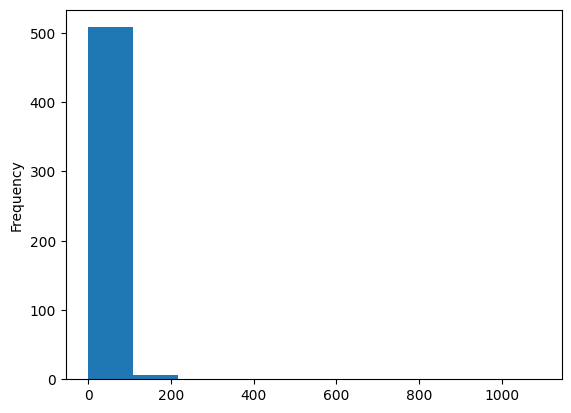

In [14]:
forest_df['area'].plot(kind='hist')

<Axes: >

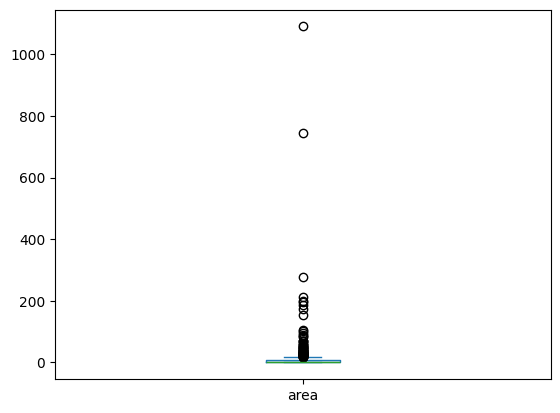

In [15]:
forest_df['area'].plot(kind='box')

**Para reducir estas diferencias, vamos a tomar logaritmos. Mediante el uso del método `apply` de `pandas` y de la función `log` de `numpy`, obtén esta nueva versión de la variable `area` y asígnala a la columna `area_ln`. Vuelve a visualizar tanto su histograma como su diagrama de cajas:**

**IMPORTANTE: el logaritmo neperiano de 0 no está definido, recuerda sumar 1 al área para hacer una correcta conversión**

In [16]:
forest_df['area_ln'] = forest_df['area'].apply(lambda x: log(x+1))

<Axes: ylabel='Frequency'>

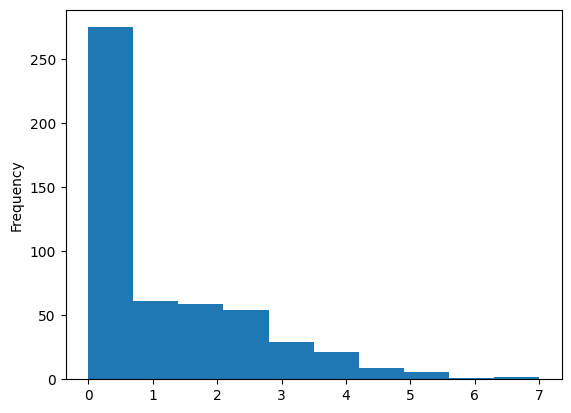

In [17]:
forest_df['area_ln'].plot(kind='hist')

<Axes: >

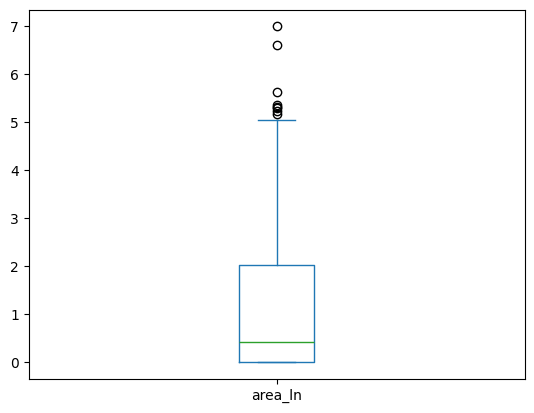

In [18]:
forest_df['area_ln'].plot(kind='box')

## Conjunto de datos `Fotocasa`

En este bloque trabajamos con un dataset real de viviendas extraído de Fotocasa.

El objetivo es predecir el **precio de un inmueble**, por lo que nos encontramos ante un problema de **regresión**.

---

## Características del dataset

El dataset incluye variables como:

- Superficie de la vivienda
- Ubicación (provincia, municipio, barrio)
- Características del inmueble (habitaciones, baños, etc.)
- Servicios adicionales (ascensor, parking, aire acondicionado…)

Estas variables son de distinta naturaleza:

- Numéricas
- Categóricas
- Booleanas

---

## Objetivo

Aplicar todo el pipeline de Machine Learning visto anteriormente:

1. Selección de variables relevantes
2. Preprocesado de datos
3. Normalización
4. División en entrenamiento y test
5. Entrenamiento de una red neuronal (MLPRegressor)
6. Optimización de hiperparámetros
7. Evaluación del modelo

---

## Importante

Este dataset representa un caso más cercano a un problema real, donde:

- Los datos no están perfectamente limpios
- Existen variables heterogéneas
- Es necesario tomar decisiones de preprocesado

---

## Enfoque

A diferencia de los ejemplos anteriores, este bloque tiene un enfoque más práctico:

- No se introducen nuevos conceptos teóricos
- Se consolidan los conocimientos adquiridos
- Se pone el foco en la correcta aplicación del pipeline completo

In [19]:
fotocasa_df = pd.read_csv("https://drive.google.com/uc?export=view&id=1RRUZxfKXsPjnC34c2_r38hk5S_BBE9ei", index_col = 0)
fotocasa_df['Tipo'] = fotocasa_df['Tipo'].astype('category')
fotocasa_df['Ascensor'] = fotocasa_df['Ascensor'].astype('category')
fotocasa_df['Amueblado'] = fotocasa_df['Amueblado'].astype('category')
fotocasa_df['Depósito'] = fotocasa_df['Depósito'].astype('category')
fotocasa_df['Gastos de comunidad'] = fotocasa_df['Gastos de comunidad'].astype('category')
fotocasa_df['Consumo energía'] = fotocasa_df['Consumo energía'].astype('category')
fotocasa_df['Emisiones'] = fotocasa_df['Emisiones'].astype('category')
fotocasa_df['Planta'] = fotocasa_df['Planta'].astype('category')
fotocasa_df['Antigüedad'] = fotocasa_df['Antigüedad'].astype('category')
fotocasa_df['Calefacción'] = fotocasa_df['Calefacción'].astype('category')
fotocasa_df['Estado'] = fotocasa_df['Estado'].astype('category')
fotocasa_df['Parking'] = fotocasa_df['Parking'].astype('category')
fotocasa_df['Zona'] = fotocasa_df['Zona'].astype('category')
fotocasa_df['Orientación'] = fotocasa_df['Orientación'].astype('category')

# Redes neuronales

Este modelo de aprendizaje se inspiró en el funcionamiento de la mente humana. Al igual que ésta, las redes neuronales se componen de un numero de elementos muy simples que procesan los datos de una forma muy similar al de una neurona humana, constando de un gran número de **conexiones** con otras neuronas mediante las que se codifica el conocimiento. Una neurona artificial implementará una función flexible y sencilla que operará sobre una serie de entradas, y, a través de sus salidas, comunicará sus datos procesados como entradas a otras neuronas.

La unidad más elemental de proceso, y que utilizaremos en esta sesión, es el **perceptrón**, que implementará una función, generalmente no lineal, a partir de la combinación lineal de una serie de coeficientes o **pesos** que serán determinados a partir de los ejemplos de entrenamiento con las entradas.

<img alt="ejemplo-kappa" width="800" src="https://drive.google.com/uc?export=view&id=1rUYXaWzIySPQHxY7escmsWq4WOB1K9e0">

Donde $f$ es la función de activación, $w_i$ los pesos, $x_i$ las entradas y $w_0$ el término de sesgo.

Existen muchos tipos de función de activación que puede implementar el **perceptrón**, siendo las más comunes las siguientes:

* La función **logística**:
$$f(x) = \frac{1}{1+e^{-x}}$$

* La **tangente hiperbólica**:
$$f(x) = \frac{e^x-e^{-x}}{e^x+e^{-x}}$$

* La **función de activación lineal rectificada** o **ReLU**:

$$f(x) = max(0, x)$$







De entre los múltiples tipos de redes neuronales existentes, en esta sesión abordaremos uno muy comúnmente utilizado y apto para la mayoría de problemas de aprendizaje: **perceptrón multicapa**.

<img width="400" src="https://scikit-learn.org/stable/_images/multilayerperceptron_network.png">


Este modelo consta de una serie de capas:

* La capa más a la izquierda es la capa de **entrada** y consiste en un conjunto de neuronas que representan a los **predictores**.

* Las capas intermedias son las capas **ocultas**, compuestas por **perceptrones** que implementarán una función de activación partiendo de las salidas de la capa anterior.

* La capa más a la derecha es la capa de **salida**, que suele implementar una función de activación diferente a las neuronas de la capa oculta. En problemas de regresión tendremos un único perceptrón de salida que generalmente implementa la función **identidad**, mientras que en clasificación tendremos tantos **perceptrones** como clases, que suelen implementar la función **softmax** (función exponencial normalizada):

$$ f(z_i) = \frac{e^{z_i}}{\sum^{K}_{j=1}{e^{z_j}}}, \ \forall \ i=1, ..., K. $$


La complejidad de este modelo dependerá fundamentalmente del **número de capas ocultas** y del **número de neuronas** en cada capa. Su número dependerá de la cantidad de ejemplos que necesitemos, siendo suficientes una o dos capas ocultas para la mayoría de problemas de aprendizaje. Por otra parte, el número de neuronas de cada capa oculta suele estar entre 5 y 100, y también dependerá del número de ejemplos.

El modelo de red que vamos a estudiar es **densamente conectado**, es decir, todas las salidas de la capa anterior están conectadas con todas las neuronas de la capa actual. Si bien, en Deep Learning suele restringirse el número de conexiones, de manera que se aproveche la información localmente y no sea necesario definir tantos pesos. Además, **no hay bucles**, es decir, las salidas de capas posteriores no son reutilizadas por capas previas. Las redes con **bucles** están especialmente indicadas para problemas con información temporal (**redes espacio/temporales**) y tienen una gran complejidad.

Cuando entrenamos un modelo basado en **perceptrón multicapa**, haremos uso del algoritmo **backpropagation** o **retropropagación del gradiente**. Este algoritmo busca determinar los **pesos** internos de la capa oculta para la obtención de las salidas deseadas. Como el conjunto de pesos a ajustar y, en consecuencia, el espacio de búsqueda de la solución es muy extenso, este proceso suele ser bastante **lento** y puede encontrar una solución **no óptima** (mínimo local).

El algoritmo funcionaría de la siguiente manera:

* Se presenta un ejemplo a la red, la cual habrá sido previamente inicializada con valores de **pesos** próximos a 0 (generalmente en el rango $[-0.7, 0.7]$. Las entradas provocarán la activación sucesiva de las diferentes capas de la red neuronal hasta que se produce una salida.

* La salida conlleva un error asociado, que vendrá dado por una función de **coste**. La función de **coste** suele ser el **error cuadrático medio** tanto para **regresión** como **clasificación**, aunque en esta última también puede utilizarse la **entropía cruzada**. Para prevenir el **sobreentrenamiento**, y que los pesos alcancen valores extremos, la función de coste suele incluir un término de **regularización** $\alpha$.

* La *responsabilidad* del error se *reparte* entre las neuronas de la última capa en función de cómo los pesos de cada una han afectado al error obtenido y ajustará sus pesos consecuentemente. En este ajuste de pesos, el coeficiente de aprendizaje $\lambda$ controlará el *impacto* del error obtenido en el ajuste de pesos. Valores de $\lambda$ elevados implicarán ajustes de pesos más bruscos, mientras que valores reducidos implicarán ajustes muy sutiles.

* Se calculará, en base a la función de **coste** un nuevo error para la capa actual y la *responsabilidad* se propagará a la capa anterior, donde se producirá un nuevo ajuste de pesos. Este proceso se repetirá hasta llegar a la capa inicial.

* Presentamos un nuevo ejemplo a la red y repetimos la secuencia de pasos anteriores. Diremos que ha pasado una **época** cuando la red haya procesado todos los ejemplos. El entrenamiento finalizará cuando transcurran un número determinado de épocas o cuando el ajuste realizado por la red esté por debajo de un umbral (la red *converge*).

## Clasificación en perceptrón multicapa

La implementación del clasificador basado en perceptrón multicapa en `scikit-learn` se encuentra en la clase [`MLPClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier). Esta implementación hace uso del algoritmo **backpropagation** previamente explicado para el entrenamiento del modelo haciendo uso de la **entropía cruzada** como función de coste y **softmax** como función de activación en la capa de salida.

De los múltiples [parámetros](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier) que define esta clase, damos especial relevancia a los siguientes:

* `hidden_layer_sizes`: una lista cuya longitud será el número de capas ocultas y donde el valor del i-ésimo elemento determina el número de neuronas de la capa i.

* `activation`: que puede tomar los valores `identity`, `logistic`, `tanh` y `relu`. Para nuestros ejemplos haremos uso de la tangente hiperbólica (`tanh`), aunque la función de activación lineal rectificada (`relu`) es muy adecuada en problemas con un gran número de capas.

* `solver`: método de optimización de los pesos de la red neuronal (`lbfgs`, `sgd`, `adam`).

* `alpha`: factor de regularización para impedir el sobreentrenamiento. Son aconsejables valores en el rango $10^{-1...-7}$.

* `learning_rate`: evolución del coeficiente de aprendizaje $\lambda$ cuando la búsqueda de valores se hace por el método de descenso de gradiente estocástico (`sgd`).
  * `constant`: coeficiente fijo a lo largo de las **épocas**.
  * `invscaling`: el coeficiente se va reduciendo con el paso de las **épocas** sustancialmente.
  * `adaptative`: mantiente constante el coeficiente de aprendizaje siempre que la tasa de error se reduzca. Si durante dos épocas el error no se reduce por debajo de un umbral `tol`, se divide entre 5.

* `learning_rate_init`: valor inicial del coeficiente de aprendizaje $\lambda$.

* `max_iter`: número de **épocas** máximo para entrenar la red neuronal.

A continuación vamos a construir un clasificador basado en **perceptrón multicapa** para el conjunto de datos de `telco`. Utilizaremos como variables de entrada las columnas `tenure`, `PaperlessBilling`, `OnlineBackup`, `Contract` y `Dependents`. La variable de salida a predecir será `Churn`. Será necesario hacer uso de la función `fit_dataset_to_tree` para preparar nuestro conjunto de datos. Cuando entrenamos un clasificador con redes neuronales es **muy importante** estandarizar los datos de entrada para que el modelo entrenado sea eficaz:

In [20]:
telco_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [21]:
telco_df.loc[:,['tenure', 'PaperlessBilling', 'OnlineBackup', 'Contract', 'Dependents']].head()

,tenure,PaperlessBilling,OnlineBackup,Contract,Dependents
customerID,,,,,
7590-VHVEG,1,Yes,Yes,Month-to-month,No
5575-GNVDE,34,No,No,One year,No
3668-QPYBK,2,Yes,Yes,Month-to-month,No
7795-CFOCW,45,No,No,One year,No
9237-HQITU,2,Yes,No,Month-to-month,No


In [22]:
input_telco_df = fit_dataset_to_tree(telco_df[['tenure', 'PaperlessBilling', 'OnlineBackup', 'Contract', 'Dependents']].dropna())
input_telco_df.head()

,tenure,PaperlessBilling,Dependents,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year
customerID,,,,,,,,,
7590-VHVEG,1,1,0,False,False,True,True,False,False
5575-GNVDE,34,0,0,True,False,False,False,True,False
3668-QPYBK,2,1,0,False,False,True,True,False,False
7795-CFOCW,45,0,0,True,False,False,False,True,False
9237-HQITU,2,1,0,True,False,False,True,False,False


In [23]:
input_telco_df.dtypes

,0
tenure,int64
PaperlessBilling,int8
Dependents,int8
OnlineBackup_No,bool
OnlineBackup_No internet service,bool
OnlineBackup_Yes,bool
Contract_Month-to-month,bool
Contract_One year,bool
Contract_Two year,bool


In [24]:
scaler = preprocessing.StandardScaler().fit(input_telco_df)
inputs_normalized_df = pd.DataFrame(scaler.transform(input_telco_df))
output_telco = telco_df.iloc[:, -1]

In [25]:
inputs_normalized_df.head()

,0,1,2,3,4,5,6,7,8
0,-1.277445,0.829798,-0.654012,-0.883620,-0.525927,1.378241,0.904184,-0.514249,-0.562975
1,0.066327,-1.205113,-0.654012,1.131709,-0.525927,-0.725563,-1.105970,1.944582,-0.562975
2,-1.236724,0.829798,-0.654012,-0.883620,-0.525927,1.378241,0.904184,-0.514249,-0.562975
3,0.514251,-1.205113,-0.654012,1.131709,-0.525927,-0.725563,-1.105970,1.944582,-0.562975
4,-1.236724,0.829798,-0.654012,1.131709,-0.525927,-0.725563,0.904184,-0.514249,-0.562975


In [26]:
output_telco.head()

,Churn
customerID,
7590-VHVEG,No
5575-GNVDE,No
3668-QPYBK,Yes
7795-CFOCW,No
9237-HQITU,Yes


In [27]:
# Dividimos los datos:
# 80% entrenamiento / 20% test
X_train, X_test, y_train, y_test = train_test_split(inputs_normalized_df, output_telco, test_size=0.2, random_state=1212)

In [28]:
telco_df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


Con los subconjuntos de entrenamiento y prueba obtenidos, vamos a probar valores con los hiperparámetros más relevantes: `hidden_layer_sizes`, `alpha` y `learning_rate_init`. Haremos uso de la clase `GridSearchCV` para obtener la mejor combinación de valores mediante **validación cruzada con 5 pliegues**, intentando optimizar la **precisión** del modelo:

- El dataset se divide en 5 partes
- El modelo se entrena 5 veces
- En cada iteración:
  - Se entrena con 4 partes
  - Se valida con la restante

In [29]:
[10**(-i) for i in range(1,4)]

# Generamos posibles valores de alpha (regularización)
[10**(-i) for i in range(1,4)]  # [0.1, 0.01, 0.001]

# Definimos combinaciones de hiperparámetros
# hidden_layer_sizes: número de neuronas por capa
# alpha: regularización
# learning_rate_init: tasa de aprendizaje

# GridSearch probará todas las combinaciones
# usando validación cruzada (cv=5)

[0.1, 0.01, 0.001]

In [30]:
#hyper_params = {
    # tupla (10, 5) → dos capas ocultas, con 10 neuronas en la primera y 5 en la segunda
    #'hidden_layer_sizes': [(10, 5), (20, 10), (50, 20)],

El parámetro 'hidden_layer_sizes' en hyper_params toma una lista de listas:

```
hyper_params = {'hidden_layer_sizes': [[2], [3], [4], [5]],
```

- [2] → 1 capa oculta con 2 neuronas

- [3] → 1 capa oculta con 3 neuronas

- [4] → 1 capa oculta con 4 neuronas

- [5] → 1 capa oculta con 5 neuronas




```
hyper_params = {
    'hidden_layer_sizes': [
        (5,),        # 1 capa con 5 neuronas
        (10, 5),     # 2 capas: 10 y 5 neuronas
        (20, 10, 5)  # 3 capas: 20, 10 y 5 neuronas
    ],
```


    

Cada combinación representa una arquitectura distinta del modelo, y GridSearch probará todas para encontrar la mejor.

**Búsqueda de hiperparámetros con GridSearchCV**

En este paso utilizamos `GridSearchCV` para encontrar la mejor combinación de hiperparámetros del modelo.

Se prueban diferentes valores de:

- `hidden_layer_sizes`: arquitectura de la red
- `alpha`: regularización (control del sobreajuste)
- `learning_rate_init`: velocidad de aprendizaje

El modelo se evalúa mediante validación cruzada (cv=5), utilizando la métrica de accuracy.

In [31]:
hyper_params = {'hidden_layer_sizes': [[2], [3], [4], [5]],
                'alpha': [10**(-i) for i in range(1,4)], # fuerza de regularización
                'learning_rate_init': [10**(-i) for i in range(1,3)]} # Velocidad de aprendizaje // Espacio de búsqueda total 4x3x2 = 24

modelCV = GridSearchCV(MLPClassifier(random_state=1212, solver='sgd', max_iter=100, activation='tanh'), # Solver = optimización iterativa
                     hyper_params, cv=5, scoring='accuracy')
modelCV.fit(X_train, y_train)
results = modelCV.cv_results_
means = results['mean_test_score']
stds = results['std_test_score']
print(f"Mejor clasificador: {modelCV.best_estimator_}")
print(f"Mejor precisión: {modelCV.best_score_}")

Mejor clasificador: MLPClassifier(activation='tanh', alpha=0.001, hidden_layer_sizes=[5],
              learning_rate_init=0.1, max_iter=100, random_state=1212,
              solver='sgd')
Mejor precisión: 0.7834575516823457


Finalmente, entrenaremos un nuevo modelo basado en perceptrón multicapa con la mejor combinación obtenida haciendo uso para ello de todo el conjunto de datos de entrenamiento y evaluándolo con los datos de prueba:

In [32]:
model = MLPClassifier(random_state=1212,
                      solver='sgd',
                      hidden_layer_sizes=[4],
                      alpha=0.1,
                      learning_rate_init=0.1,
                      max_iter=100,
                      activation='tanh')
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
print(f"Precisión obtenida: {metrics.accuracy_score(y_test,y_pred)}")
print(f"Índice Kappa obtenido: {metrics.cohen_kappa_score(y_test,y_pred)}")

Precisión obtenida: 0.7920511000709723
Índice Kappa obtenido: 0.38548822365747604


### Ejercicios

**Los resultados obtenidos por la red neuronal actual no son los mejores de entre todos los modelos probados. Existen varios factores que están en nuestra mano para mejorar la calidad de las predicciones.**

**El primero de ellos es mejorar el número y la calidad de las variables de entrada. De esta manera tendrá más información para realizar la clasificación. Selecciona las variables `tenure`, `OnlineSecurity`, `PaymentMethod`, `PaperlessBilling`, `MonthlyCharges`, `Contract`, `Dependents` y `SeniorCitizen`:**

In [33]:
# Seleccionamos más variables de entrada para tener más información
cols_entrada = ['tenure', 'OnlineSecurity', 'PaymentMethod', 'PaperlessBilling',
                'MonthlyCharges', 'Contract', 'Dependents', 'SeniorCitizen']

input_telco_df = fit_dataset_to_tree(telco_df[cols_entrada].dropna())

# Estandarizamos las entradas
scaler = preprocessing.StandardScaler().fit(input_telco_df)
inputs_normalized_df = pd.DataFrame(scaler.transform(input_telco_df))

# Variable de salida (Churn)
output_telco = telco_df.iloc[:, -1]

# Dividimos en entrenamiento (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    inputs_normalized_df, output_telco, test_size=0.2, random_state=1212)

print(f"Variables de entrada: {input_telco_df.shape[1]}")
print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de test: {X_test.shape[0]}")
input_telco_df.head()

Variables de entrada: 15
Muestras de entrenamiento: 5634
Muestras de test: 1409


,tenure,PaperlessBilling,MonthlyCharges,Dependents,SeniorCitizen,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_Month-to-month,Contract_One year,Contract_Two year
customerID,,,,,,,,,,,,,,,
7590-VHVEG,1,1,29.85,0,0,True,False,False,False,False,True,False,True,False,False
5575-GNVDE,34,0,56.95,0,0,False,False,True,False,False,False,True,False,True,False
3668-QPYBK,2,1,53.85,0,0,False,False,True,False,False,False,True,True,False,False
7795-CFOCW,45,0,42.30,0,0,False,False,True,True,False,False,False,False,True,False
9237-HQITU,2,1,70.70,0,0,True,False,False,False,False,True,False,True,False,False


**El método ajuste de pesos `adam` es una versión optimizada el método de descenso de gradiente estocástico. En este caso no tendremos que ajustar el hiperparámetro `learning_rate_init`. Además, la red neuronal es un modelo con una gran tendencia al *overfitting*, por lo que es interesante probar también con diferentes valores para el número máximo de épocas (`max_iter`).**

**A continuación entrena una nueva red neuronal para regresión probando valores con los hiperparámetros `hidden_layer_sizes`, `alpha` y `max_iter`:**

**PISTA: en este caso, es aconsejable que el número de neuronas de la capa oculta sea reducido.**

In [34]:
[10**(-i) for i in range(2,7)]

[0.01, 0.001, 0.0001, 1e-05, 1e-06]

In [35]:
# Ahora usamos adam como solver, que no necesita ajustar learning_rate_init.
# Probamos también con distintos valores de max_iter para controlar el overfitting.

hyper_params = {
    'hidden_layer_sizes': [[2], [3], [4], [5]],
    'alpha': [10**(-i) for i in range(2, 7)],   # de 0.01 a 0.000001
    'max_iter': [50, 100, 200]
}

modelCV = GridSearchCV(
    MLPClassifier(random_state=1212, solver='adam', activation='tanh'),
    hyper_params, cv=5, scoring='accuracy'
)

modelCV.fit(X_train, y_train)

print(f"Mejor clasificador: {modelCV.best_estimator_}")
print(f"Mejor precisión en validación: {modelCV.best_score_}")

Mejor clasificador: MLPClassifier(activation='tanh', alpha=0.01, hidden_layer_sizes=[5],
              max_iter=100, random_state=1212)
Mejor precisión en validación: 0.7960609991158407


**Finalmente, entrena un nuevo modelo con la mejor combinación de valores de hiperparámetros obtenida y evalúalo con el conjunto de prueba. ¿Mejora la precisión obtenida? Si no es así, prueba con un número máximo de épocas inferior al obtenido en la fase de validación (50).**

In [36]:
# Entrenamos con la mejor combinación obtenida por GridSearch.
# Si no mejora, probamos con max_iter=50 como sugiere el enunciado.

best = modelCV.best_params_
print(f"Mejores hiperparámetros encontrados: {best}")

model = MLPClassifier(
    random_state=1212,
    solver='adam',
    hidden_layer_sizes=best['hidden_layer_sizes'],
    alpha=best['alpha'],
    max_iter=50,  # probamos con 50 si el resultado del GridSearch no mejora
    activation='tanh'
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Precisión obtenida: {metrics.accuracy_score(y_test, y_pred)}")
print(f"Índice Kappa obtenido: {metrics.cohen_kappa_score(y_test, y_pred)}")

Mejores hiperparámetros encontrados: {'alpha': 0.01, 'hidden_layer_sizes': [5], 'max_iter': 100}
Precisión obtenida: 0.794180269694819
Índice Kappa obtenido: 0.43357176522775787


**¿Mejoraríamos la precisión si hiciéramos uso de varias capas ocultas? ¿Y cambiando el valor de la semilla aleatoria?**


*No tiene por qué mejorar. Con pocos datos y pocas variables, meter más capas ocultas lo que suele hacer es sobreajustar, no generalizar mejor. Una o dos capas con pocas neuronas ya es suficiente para este tipo de problemas.
Lo de la semilla, sí que cambia el resultado porque afecta a cómo se inicializan los pesos. Pero si solo mejora con una semilla concreta, no es que el modelo sea mejor, es que hemos tenido suerte con esa partición. Para comparar de verdad hay que fiarse de la validación cruzada.*

## Regresión en perceptrón multicapa

En este caso, la implementación del regresor viene dada por la clase [MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html#sklearn.neural_network.MLPRegressor) que hace uso del **error cuadrático medio** como función de coste y la función **identidad** como función de activación en la capa de salida, siendo los parámeros relevantes los mismos que en `MLPClassifier`.

Cuando trabajamos con modelos de aprendizaje basados en redes neuronales es **muy importante** estandarizar los datos de entrada y los de **salida**, ya que las funciones de activación nos devolverán los valores acotados en un rango.

A continuación vamos a construir un clasificador basado en **perceptrón multicapa** para el conjunto de datos de `forest`. Utilizaremos como variables de entrada las columnas `wind`, `temp`, `RH` y `rain`. La variable de salida será `area_ln`:

In [37]:
inputs_forest_df = forest_df[['wind', 'temp', 'RH', 'rain']]
output_forest = forest_df['area_ln']
scaler = preprocessing.StandardScaler().fit(inputs_forest_df)
inputs_forest_normalized_df = scaler.transform(inputs_forest_df)
output_scaler = preprocessing.StandardScaler().fit(output_forest.values.reshape(-1, 1))
# La salida también se estandariza
output_forest_normalized = output_scaler.transform(output_forest.values.reshape(-1, 1)).reshape(1,-1)[0]
X_train, X_test, y_train, y_test = train_test_split(inputs_forest_normalized_df, output_forest_normalized, test_size=0.2, random_state=1212)

Con los subconjuntos de entrenamiento y prueba obtenidos, vamos a buscar la mejor combinación de los siguientes hiperparámetros: `hidden_layer_sizes`, `alpha` y `max_iter`. Haremos uso de la clase `GridSearchCV` para obtener la mejor combinación de valores mediante **validación cruzada con 5 pliegues**, intentando optimizar el **error absoluto medio** del modelo:

In [38]:
hyper_params = {'hidden_layer_sizes': [[2], [3], [4], [5]],
                'alpha': [10**(-i) for i in range(1,4)],
                'max_iter': [200, 300, 400, 500],
              }
modelCV = GridSearchCV(MLPRegressor(solver='lbfgs', activation='tanh', random_state=1212),
                     hyper_params, cv=5, scoring='neg_mean_absolute_error')
modelCV.fit(X_train, y_train)
results = modelCV.cv_results_
means = results['mean_test_score']
stds = results['std_test_score']
print(f"Mejor clasificador: {modelCV.best_estimator_}")
print(f"Mínimo error absoluto medio: {modelCV.best_score_}")

Mejor clasificador: MLPRegressor(activation='tanh', alpha=0.1, hidden_layer_sizes=[4],
             random_state=1212, solver='lbfgs')
Mínimo error absoluto medio: -0.7972461992817086


scikit-learn pone el error en negativo porque GridSearchCV siempre intenta maximizar la métrica. Como el MAE hay que minimizarlo, lo convierte a negativo.

Entonces:

- -0.798... en realidad significa
- MAE = 0.798...

Cuanto más cerca de 0 esté ese valor negativo, mejor.
Porque significa menor error absoluto medio.

A continuación vamos a entrenar un modelo haciendo uso de la mejor combinación de valores obtenida. **No olvidemos que el error absoluto medio está obtenido en base a una salida estandarizada**, por lo que tendremos que **desestandarizarlo**:  

In [39]:
model = MLPRegressor(solver='lbfgs', hidden_layer_sizes=[4], alpha=0.1, random_state=1212, max_iter=200, activation='tanh')
model.fit(X_train, y_train)

# Desestandarizamos las predicciones para volver a la escala real
y_pred = output_scaler.inverse_transform(model.predict(X_test).reshape(-1,1))

# Desestandarizamos también los valores reales de test
y_real = output_scaler.inverse_transform(y_test.reshape(-1,1))

# Calculamos métricas en la escala original
rmse = np.sqrt(metrics.mean_squared_error(y_real, y_pred))
print(f"Raíz del error cuadrático medio: {rmse}")
print(f"Error absoluto medio: {metrics.mean_absolute_error(y_real,y_pred)}")

Raíz del error cuadrático medio: 1.5378754949629214
Error absoluto medio: 1.215821758935412


**Interpretación de resultados**

El modelo presenta un error absoluto medio de aproximadamente **1.24 unidades**, lo que indica el error medio de predicción en la escala real del problema.

La métrica RMSE es superior al MAE, lo que sugiere que existen algunas predicciones con errores más elevados, ya que esta métrica penaliza más intensamente los errores grandes.

En conjunto, estas métricas permiten evaluar el rendimiento real del modelo de regresión en datos no vistos.

In [40]:
y_pred

array([[ 0.93077742],
       [ 0.76185633],
       [-0.56424329],
       [ 0.92687717],
       [ 0.92737205],
       [ 0.93204782],
       [ 1.32335137],
       [ 1.80579359],
       [ 1.0264    ],
       [ 0.89189006],
       [ 0.74832057],
       [ 0.91410986],
       [-0.45321817],
       [ 2.34690954],
       [ 0.92788241],
       [ 0.92977655],
       [ 0.93146958],
       [ 0.92994902],
       [ 1.32305922],
       [ 0.93739827],
       [ 0.92899054],
       [ 0.9527969 ],
       [ 0.93313535],
       [ 0.93221501],
       [ 1.02036444],
       [ 1.13873648],
       [ 0.92900401],
       [ 0.93090671],
       [ 1.05001465],
       [ 0.92836509],
       [ 1.43652821],
       [ 0.73639195],
       [ 0.76321383],
       [ 0.92719999],
       [ 1.48188102],
       [ 0.81427282],
       [ 0.93814315],
       [ 0.93077763],
       [ 1.36200991],
       [ 0.93594487],
       [ 0.93130261],
       [ 1.23748418],
       [ 0.92311372],
       [ 1.2530357 ],
       [ 1.01053416],
       [ 1

Aquí estamos mostrando las predicciones del modelo sobre los datos de prueba. Cada número corresponde al valor que la red neuronal estima para una muestra del conjunto de test

#### Ejercicios

In [41]:
fotocasa_df.head(2)

,Precio,Título,Descripción,Fotos,Dirección,Inmobiliaria,Anunciante,Habitaciones,Baños,Superficie,...,Planta,Antigüedad,Calefacción,Terraza,Balcón,Orientación,Estado,Parking,Trastero,Zona
ID,,,,,,,,,,,,,,,,,,,,,
157876626,500,Apartamento de alquiler en Centro,Maravilloso apartamento para entrar a vivir en...,21,Centro,True,BREXTOM MURCIA,1.0,1.0,46.0,...,2ª planta,30 a 50 años,True,False,False,Desconocida,Desconocido,No,False,Centro
157690261,900,Piso de alquiler en Doctor Marañón Centro,Se alquila estupenda vivienda recién reformada...,18,Doctor Marañón Centro,True,ABAD SERVICIOS INMOBILIARIOS,4.0,2.0,169.0,...,3ª planta,Desconocida,True,True,True,Desconocida,Desconocido,No,False,Centro


**En los siguientes ejercicios vamos a entrenar un regresor basado en redes neuronales para el conjunto de datos de inmuebles en alquiler `fotocasa_df`. A continuación te indicamos una serie de variables de entrada a utilizar:**

In [42]:
inputs = ['Superficie', 'Habitaciones', 'Baños', 'Aire acondicionado', 'Inmobiliaria',
          'Ascensor', 'Electrodomésticos', 'Amueblado', 'Gastos de comunidad',
          'Balcón', 'Planta', 'Zona', 'Parking']

**Haciendo uso del método `fit_dataset_to_tree`, prepara el conjunto de variables de entrada para su uso por la clase `MLPRegressor`. Asigna el `DataFrame` con los predictores a la variable `inputs_fotocasa_df` y la salida `Precio` a la variable `output_fotocasa`:**

In [43]:
# Preparamos las variables de entrada con fit_dataset_to_tree
# para convertir las categóricas a numéricas
inputs_fotocasa_df = fit_dataset_to_tree(fotocasa_df[inputs].dropna())

# La variable de salida es el precio
output_fotocasa = fotocasa_df['Precio']

print(f"Dimensiones de entrada: {inputs_fotocasa_df.shape}")
inputs_fotocasa_df.head()

Dimensiones de entrada: (434, 38)


,Superficie,Habitaciones,Baños,Aire acondicionado,Inmobiliaria,Ascensor,Electrodomésticos,Amueblado,Gastos de comunidad,Balcón,...,Zona_Espinardo,Zona_Juan Carlos I,Zona_Juan de Borbón - La Flota,Zona_Ronda Sur,Zona_San Andrés - San Antón,Zona_Santa María de Gracia,Zona_Vistabella,Parking_Comunitario,Parking_No,Parking_Privado
ID,,,,,,,,,,,,,,,,,,,,,
157876626,46.0,1.0,1.0,True,True,1,True,0,0,False,...,False,False,False,False,False,False,False,False,True,False
157690261,169.0,4.0,2.0,True,True,1,True,0,0,True,...,False,False,False,False,False,False,False,False,True,False
158258497,77.0,2.0,1.0,True,True,1,True,1,0,True,...,False,False,False,False,False,False,False,False,False,True
158184359,104.0,3.0,2.0,False,True,1,True,0,1,True,...,False,False,False,False,False,False,False,False,False,True
158198300,101.0,3.0,2.0,False,True,1,True,1,0,True,...,False,False,True,False,False,False,False,False,False,True


**A continuación escala tanto las variables de <u>entrada</u> como las de <u>salida</u> haciendo uso de la clase `StandardScaler`. Almacena los resultados en las variables `inputs_normalized_df` y `output_fotocasa_normalized`:**

In [44]:
# Escalamos las entradas
scaler_in = preprocessing.StandardScaler().fit(inputs_fotocasa_df)
inputs_normalized_df = pd.DataFrame(scaler_in.transform(inputs_fotocasa_df))

# Escalamos también la salida (precio), que es necesario en regresión con MLP
output_scaler = preprocessing.StandardScaler().fit(output_fotocasa.values.reshape(-1, 1))
output_fotocasa_normalized = output_scaler.transform(
    output_fotocasa.values.reshape(-1, 1)
).reshape(1, -1)[0]

print(f"Entradas normalizadas: {inputs_normalized_df.shape}")
print(f"Salida normalizada: media={output_fotocasa_normalized.mean():.4f}, std={output_fotocasa_normalized.std():.4f}")

Entradas normalizadas: (434, 38)
Salida normalizada: media=-0.0000, std=1.0000


**Divide a continuación el conjunto de datos en los subconjuntos de <u>entrenamiento</u> y <u>prueba</u>:**

In [45]:
# Dividimos en 80% entrenamiento y 20% test
X_train, X_test, y_train, y_test = train_test_split(
    inputs_normalized_df, output_fotocasa_normalized,
    test_size=0.2, random_state=1212
)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de test: {X_test.shape[0]}")

Muestras de entrenamiento: 347
Muestras de test: 87


**Haciendo uso de <u>validación cruzada</u> con 5 pliegues, el conjunto de datos de <u>entrenamiento</u> y la clase `GridSearchCV`, entrena un regresor basado en perceptrón multicapa:**

**Prueba con los siguientes combinaciones de hiperparámetros:**

* **Capas ocultas (`hidden_layer_sizes`)**:
  * **Una capa de 1, 2, 3, 5 y 10 neuronas**.
  * **Dos capas con 1 neurona y 2 neuronas respectivamente**.

* **Factor de regularización (`alpha`): $10^{-2}$, $10^{-3}$ y $10^{-4}$**.
* **Máximo de iteraciones (`max_iter`): 50 y 500**.
* **Semilla aleatoria (`random_state`): 1212, 4464**.
* **Función de activación (`activation`): `relu`**.
* **Sistema de optimización de pesos (`solver`): `adam`**.
* **Tolerancia para la optimización (`tol`): 0**.

In [46]:
# Definimos los hiperparámetros que nos piden probar
hyper_params = {
    'hidden_layer_sizes': [[1], [2], [3], [5], [10], [1, 2]],
    'alpha': [10**(-i) for i in range(2, 5)],    # 0.01, 0.001, 0.0001
    'max_iter': [50, 500],
    'random_state': [1212, 4464]
}

modelCV = GridSearchCV(
    MLPRegressor(solver='adam', activation='relu', tol=0),
    hyper_params, cv=5, scoring='neg_mean_absolute_error'
)

modelCV.fit(X_train, y_train)

print(f"Mejor regresor: {modelCV.best_estimator_}")
print(f"Mínimo error absoluto medio (negado): {modelCV.best_score_}")

Mejor regresor: MLPRegressor(hidden_layer_sizes=[2], max_iter=500, random_state=4464, tol=0)
Mínimo error absoluto medio (negado): -0.4603893754010418


**Haciendo uso del conjunto de datos de entrenamiento y la mejor combinación de hiperparámetros obtenida, entrena un regresor basado en perceptrón multicapa y evalúa su eficacia haciendo uso del conjunto de datos de prueba. Para ello, muestra la raíz del error cuadrático medio obtenida:**

In [47]:
# Entrenamos con los mejores hiperparámetros
best = modelCV.best_params_
print(f"Mejores hiperparámetros: {best}")

model = MLPRegressor(
    solver='adam',
    activation='relu',
    tol=0,
    hidden_layer_sizes=best['hidden_layer_sizes'],
    alpha=best['alpha'],
    max_iter=best['max_iter'],
    random_state=best['random_state']
)

model.fit(X_train, y_train)

# Desestandarizamos las predicciones y los valores reales
y_pred = output_scaler.inverse_transform(model.predict(X_test).reshape(-1, 1))
y_real = output_scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = np.sqrt(metrics.mean_squared_error(y_real, y_pred))
mae = metrics.mean_absolute_error(y_real, y_pred)

print(f"Raíz del error cuadrático medio (RMSE): {rmse}")
print(f"Error absoluto medio (MAE): {mae}")

Mejores hiperparámetros: {'alpha': 0.0001, 'hidden_layer_sizes': [2], 'max_iter': 500, 'random_state': 4464}
Raíz del error cuadrático medio (RMSE): 157.47094176387148
Error absoluto medio (MAE): 114.57357585638188


In [48]:
y_pred

array([[ 569.1956859 ],
       [ 565.27534361],
       [ 631.19117633],
       [ 710.02572052],
       [ 569.1956859 ],
       [ 673.51797814],
       [ 502.49786211],
       [ 728.7325025 ],
       [ 650.15711345],
       [ 450.70132466],
       [ 260.67976105],
       [1114.27629037],
       [ 555.57863873],
       [1002.62969519],
       [ 795.94255833],
       [ 733.32243547],
       [ 736.85079018],
       [ 776.77391135],
       [ 474.76631143],
       [ 773.68862378],
       [ 577.2417823 ],
       [ 569.1956859 ],
       [ 327.25269511],
       [1051.18872688],
       [ 820.96155053],
       [ 489.17318164],
       [ 650.30064419],
       [ 831.88555688],
       [ 429.37775482],
       [ 533.97041995],
       [ 539.82298145],
       [ 605.5376408 ],
       [ 569.1956859 ],
       [ 630.64808704],
       [ 417.56357804],
       [ 681.70520295],
       [ 772.78816275],
       [ 350.22436334],
       [ 567.04057569],
       [ 567.46907736],
       [ 931.54010899],
       [ 589.868

**¿Has obtenido un buen resultado? ¿A qué crees que puede deberse?**

*El resultado no es muy bueno. El error sale alto comparado con el rango de precios. Tiene sentido: el precio de un piso depende de cosas que no están en el dataset (ubicación exacta, estado real del inmueble, cercanía a transporte...). Además, los datos de Fotocasa son reales y vienen con ruido, no es un dataset limpio de ejemplo. Con un perceptrón multicapa sencillo y estas variables es difícil que el modelo acierte mucho.*